In [7]:
import glob as glob
import json
import matplotlib.pyplot as plt


In [8]:
# 1. Load data
foldername = "../benign/*"
filenames = glob.glob(foldername)

## Displaying F1 Score vs. Epsilon

In [4]:
x, y= [], []

for filename in filenames:
    with open(filename, 'r') as file:
        data = json.load(file)
        if not 'eps' in data.keys(): 
            continue
        x.append(data['eps'])
        y.append(data['f1'])

x, y

([], [])

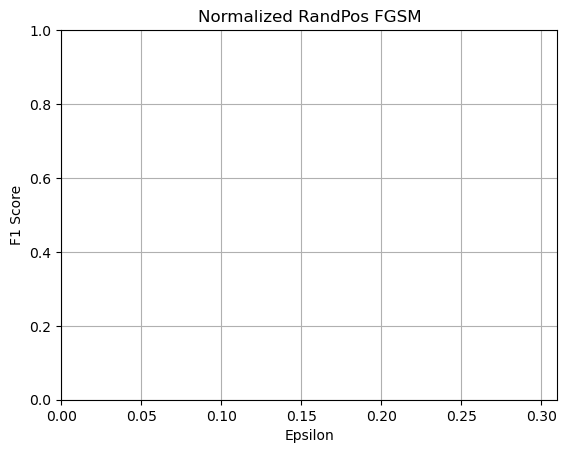

In [5]:
# For adv_test - plot F1 score vs. epsilon
# 2. Create the line plot
plt.scatter(x, y, color='blue', marker="o")

# 3. Add titles and labels
plt.title("Normalized RandPos FGSM")
plt.xlabel("Epsilon")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xlim(0, 0.31)
plt.grid(True)

# 4. Display the graph

## Displaying F1 Score vs. Run type

In [ ]:
cat_vals = {}
for filename in filenames:
    with open(filename, 'r') as file:
        data = json.load(file)
        norm_type = "Denorm" if "denorm" in filename else "Norm"
        
        # Loop through each run and average the results
        for run in (data["benign"]):
            wrapper_type = "Wrapper" if run["wrapper"] else "Og"
            key = f"{norm_type}-{wrapper_type}"

            if not key in cat_vals.keys():
                cat_vals[key] = []

            cat_vals[key].append(run["f1"])


cat_vals

KeyError: 'Denorm-Wrapper'

dict_keys(['Denorm-Wrapper', 'Denorm-Og', 'Norm-Wrapper', 'Norm-Og']) dict_values([0.9829195656898114, 0.9714426699563232, 0.9917344098986437, 0.9860291034334886])


Text(0.5, 1.0, 'F1 Score vs. Run Type')

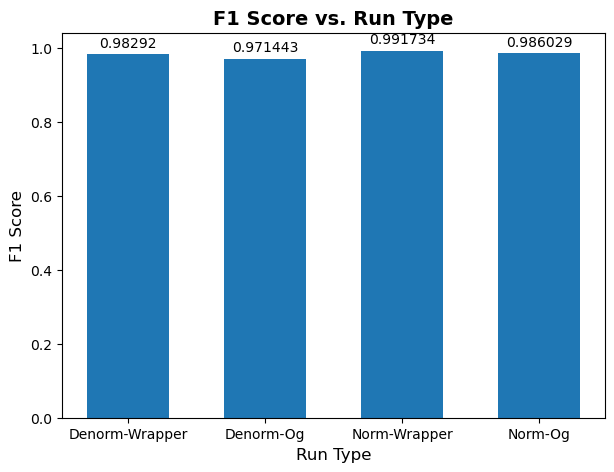

In [20]:
cats = cat_vals.keys()
vals = cat_vals.values()
print(cats, vals)
# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 5))

# Plot vertical bars
bars = ax.bar(cats, vals, width=0.6)
ax.bar_label(bars, padding=3)
# ax.set_ylim(0.95, 1.0)

# Customizing labels and title
ax.set_xlabel('Run Type', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score vs. Run Type', fontsize=14, fontweight='bold')